# 11 · Endogenous oscillation — the forgetting bifurcation

**The diagnosis.** Notebooks 06–10 all produce the same *kind* of object: a
trajectory that **settles**. μ̄ rises and parks; factions merge; the
hysteresis loop traces once and dies. That is structural — the model is a
*gradient flow to consensus*. Every component is a **contraction**:
precision-weighted pooling is a row-stochastic average, the conjugate
update is a ratchet, the trust update decays geometrically. A composition
of contractions has, by Banach, a unique fixed point.

**The question.** Can the model ever *not* settle — sustained, endogenous
motion with the environment θ\* held perfectly constant? And if so, what
*kind* of motion?

**What this notebook finds (stated honestly up front).** One principled
change — exponential forgetting that reverts belief toward the paradigm
prior (`src/inference.py`) — plus attention left free to roam across the
K = 3 bands of the world, and the model crosses a **Hopf-type
bifurcation**: below a forgetting threshold the consensus fixed point loses
stability and the population settles onto a **sustained limit cycle** —
belief perpetually swinging between the paradigm prior and the evidence, at
constant θ\*.

It is *not* chaos, and that is itself a result, not a failure. A
parameter sweep (§6) finds no positive Lyapunov exponent anywhere: the
model is a *piecewise* contraction, and a piecewise contraction can do
exactly one interesting thing — settle onto a periodic orbit. It cannot
stretch-and-fold. Genuine chaos would need an *expanding* mechanism this
model class does not contain. So the honest, defensible claim is: **belief
forgetting converts a convergence machine into a clean nonlinear
oscillator** — and that is already a sharp dissociation from any Bayesian
rule-induction baseline, which only ever has the fixed point.

**The two levers** (§1):
- **Belief forgetting** `ρ_post < 1` — the carried-forward posterior is a
  convex blend of yesterday's posterior and a fixed *paradigm prior*, so an
  unobserved belief component relaxes back toward the prior while
  observations pull it toward the truth. A standing tension. New in
  `src/inference.py`.
- **Unlocked, hysteretic attention** — each agent picks which of K = 3
  *bands* of the world to probe (a band is a region of experiment-space
  carrying information about one component of θ; the Gaussian-bump basis
  `h_k(x)` makes band k legible only near its peak `x_k`). A small
  switching cost gives attention *inertia*, so an agent *dwells* in a band
  — and the dwell time is set by `ρ_post`, which makes forgetting a genuine
  oscillator-frequency knob.

The arc: §2 the single-agent oscillator (the unit cell) → §3 a coupled
pair → §4 the network at constant θ\* → §5 characterising the attractor
(and ruling out chaos) → §6 the forgetting bifurcation → §7 the
dissociation (`ρ_post = 1` is the convergent Bayesian-rigidity baseline).

In [1]:
import sys, os
from functools import partial
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns

from src.network import build_adjacency

sns.set_theme(context='notebook', style='whitegrid')
np.set_printoptions(precision=4, suppress=True)
print('imports ok')

imports ok


## §1 · The two levers

**The world.** K = 3 *bands*. Band k is a Gaussian bump
`h_k(x) = exp(-(x - x_k)² / w²)` peaked at `x_k ∈ {2, 4, 6}` — an
experiment at `x = x_k` carries information about θ_k and almost nothing
about the others. The truth is the *constant* vector `θ* = (1.0, 1.5, 2.0)`
(asymmetric, so the bands are not interchangeable). An observation is
`o ~ N(h(x)·θ*, σ²)`.

**Belief.** Each agent holds a Gaussian over θ ∈ ℝ³ — mean `μ`, precision
matrix `Λ`. The private update is the **prior-reverting exponential-
forgetting filter** now in `src/inference.py` (here, the vector version):
the prior carried into a step is the information-form convex blend

$$\Lambda_{\text{carry}} = \rho\,\Lambda + (1-\rho)\,\Lambda_p,\qquad
\Lambda_{\text{carry}}\mu_{\text{carry}} = \rho\,\Lambda\mu + (1-\rho)\,\Lambda_p\mu_p,$$

so an unobserved component relaxes geometrically toward the paradigm prior
`μ_p` (rate `1-ρ`), while observations pull it toward the truth. At
`ρ_post = 1` this collapses to the old ratchet.

**Attention with inertia.** Each step every agent picks one band to probe
by expected information gain `EIG_k`, but with **hysteresis**: it keeps its
current band unless another band beats it by more than a switching cost
`c_switch`. The dwell time then depends on `ρ_post` — slow forgetting → the
neglected bands take longer to become attractive → longer dwell → slower
oscillation. That is what makes `ρ_post` a frequency knob.

**Coupling.** Agents pool beliefs precision-weighted over the trust-learned
graph (Gamma-conjugate trust, forgetting `ρ_trust`). The coupling strength
`κ` scales the off-diagonal adjacency: `A_self = I + κ·A_adj`.

Everything below is notebook-local (the vector world stays out of `src/`,
per the project's standing decision); `private_update_vec` mirrors the
`src/inference.py` forgetting formula exactly.

In [2]:
# ---------------------------------------------------------------- world
K = 3
X_PEAKS = jnp.array([2.0, 4.0, 6.0])          # band centres
X_GRID = X_PEAKS                               # action grid = the K bands
BASIS_W = 0.6
SIGMA = 1.0
THETA_STAR = jnp.array([1.0, 1.5, 2.0])        # constant, asymmetric truth
PRIOR_MU = jnp.zeros(K)                        # the paradigm prior mean
LAMBDA0_PRIOR = 1.0                            # paradigm prior precision
PRIOR_LAMBDA = jnp.eye(K, dtype=jnp.float32) * LAMBDA0_PRIOR
EPS = 1e-9


def h_basis(x):
    """(..., K) Gaussian-bump basis values at x."""
    x_ = jnp.asarray(x)[..., None]
    return jnp.exp(-((x_ - X_PEAKS) ** 2) / (BASIS_W ** 2))


# ------------------------------------------- inference (prior-reverting)
def private_update_vec(mu, Lambda, x, o, posterior_rho, prior_Lambda):
    """Prior-reverting exponential-forgetting Gaussian filter. posterior_rho
    is (N,). Mirrors src/inference.py:private_update — the carried prior is
    the convex blend rho*(posterior) + (1-rho)*(paradigm prior)."""
    h = h_basis(x)                                       # (N, K)
    sigma2 = SIGMA ** 2
    HHT = h[:, :, None] * h[:, None, :] / sigma2          # (N, K, K)
    rho = posterior_rho[:, None, None]                    # (N, 1, 1)
    pL = prior_Lambda[None]                               # (1, K, K)
    Lambda_carry = rho * Lambda + (1.0 - rho) * pL
    Lmu_carry = (jnp.einsum('nij,nj->ni', rho * Lambda, mu)
                 + jnp.einsum('nij,nj->ni', (1.0 - rho) * pL,
                              jnp.broadcast_to(PRIOR_MU, mu.shape)))
    Lambda_new = Lambda_carry + HHT
    rhs = Lmu_carry + h * (o[:, None]) / sigma2           # h0 = 0
    mu_new = jax.vmap(jnp.linalg.solve)(Lambda_new + EPS * jnp.eye(K)[None], rhs)
    return mu_new, Lambda_new


def precision_pool_vec(mu_priv, Lambda_priv, gamma, mask):
    """Multivariate precision-weighted social pool (copied from nb10)."""
    weights = gamma * mask
    w = weights / (weights.sum(axis=1, keepdims=True) + EPS)
    Lambda_pool = jnp.einsum('ij,jkl->ikl', w, Lambda_priv)
    Lmu_priv = jnp.einsum('jkl,jl->jk', Lambda_priv, mu_priv)
    num = jnp.einsum('ij,jk->ik', w, Lmu_priv)
    mu_pool = jax.vmap(jnp.linalg.solve)(Lambda_pool + EPS * jnp.eye(K)[None], num)
    return mu_pool, Lambda_pool


def surprisal_matrix_vec(mu_priv, Lambda_priv, x_obs, o_obs, mask):
    """eps_ij = -log q_j^priv(o_i | x_i) over the closed neighbourhood
    (copied from nb10)."""
    h_i = h_basis(x_obs)
    def per_j(Lj):
        return jax.vmap(lambda h: jnp.linalg.solve(Lj + EPS * jnp.eye(K), h))(h_i)
    Sigma_h = jax.vmap(per_j)(Lambda_priv)
    quad = jnp.einsum('ik,jik->ij', h_i, Sigma_h)
    pred_mean = h_i @ mu_priv.T
    pred_var = SIGMA ** 2 + quad
    log_p = (-0.5 * jnp.log(2 * jnp.pi * pred_var)
             - 0.5 * (o_obs[:, None] - pred_mean) ** 2 / pred_var)
    return (-log_p) * mask


def expected_info_gain_vec(Lambda, x_grid):
    """EIG_i(x) = 1/2 logdet(Lambda + HHT) - 1/2 logdet(Lambda). (N, G)."""
    _, ld_old = jnp.linalg.slogdet(Lambda + EPS * jnp.eye(K)[None])
    h_grid = h_basis(x_grid)
    HHT = h_grid[..., :, None] * h_grid[..., None, :] / (SIGMA ** 2)
    Lambda_post = Lambda[:, None] + HHT
    _, ld_new = jnp.linalg.slogdet(Lambda_post + EPS * jnp.eye(K)[None, None])
    return 0.5 * (ld_new - ld_old[:, None])


# ------------------------------------------------------------ the dynamics
@partial(jax.jit, static_argnames=('deterministic',))
def step_vec(state, A_self, posterior_rho, rho_trust, switch_cost, prior_Lambda,
             deterministic=True):
    """One world-step. A_self, posterior_rho (N,), rho_trust, switch_cost
    are traced -> parameter sweeps reuse one compilation. deterministic=True
    uses noise-free observation, making the map a genuine deterministic
    dynamical system (used for the Lyapunov / Poincare / bifurcation work)."""
    key_pol, key_obs, key_next = jax.random.split(state['key'], 3)
    Lambda = state['Lambda']
    N = Lambda.shape[0]

    eig = expected_info_gain_vec(Lambda, X_GRID)            # (N, K)
    # attention with hysteresis: keep the current band unless another beats
    # it by more than switch_cost. dwell time becomes rho_post-dependent.
    prev = state['idx_prev']                                # (N,)
    stay_eig = jnp.take_along_axis(eig, prev[:, None], axis=1)[:, 0]
    best_idx = jnp.argmax(eig, axis=1)
    best_eig = jnp.max(eig, axis=1)
    switch = best_eig > stay_eig + switch_cost
    idx = jnp.where(switch, best_idx, prev)
    x_chosen = X_GRID[idx]                                  # (N,)

    mean_o = jnp.sum(h_basis(x_chosen) * THETA_STAR[None, :], axis=1)   # (N,)
    if deterministic:
        o_obs = mean_o
    else:
        o_obs = mean_o + jax.random.normal(key_obs, (N,)) * SIGMA

    mu_priv, Lambda_priv = private_update_vec(state['mu'], Lambda, x_chosen,
                                              o_obs, posterior_rho, prior_Lambda)
    mu_pool, Lambda_pool = precision_pool_vec(mu_priv, Lambda_priv,
                                              state['gamma'], A_self)
    epsilon = surprisal_matrix_vec(mu_priv, Lambda_priv, x_chosen, o_obs, A_self)
    alpha_new = rho_trust * state['alpha'] + A_self
    beta_new = rho_trust * state['beta'] + epsilon
    gamma_raw = (alpha_new / (beta_new + EPS)) * A_self
    gamma_new = (gamma_raw / (gamma_raw.sum(1, keepdims=True) + EPS)) * A_self

    new_state = dict(mu=mu_pool, Lambda=Lambda_pool, alpha=alpha_new,
                     beta=beta_new, gamma=gamma_new, idx_prev=idx, key=key_next)
    return new_state, dict(idx=idx, x=x_chosen, o=o_obs)


@partial(jax.jit, static_argnames=('T', 'deterministic'))
def rollout(init_state_, A_self, posterior_rho, rho_trust, switch_cost,
            prior_Lambda, T, deterministic=True):
    """T-step rollout via lax.scan. Records per-step (mu_all, lam_diag, idx,
    mu_mean)."""
    def scan_step(st, _):
        ns, aux = step_vec(st, A_self, posterior_rho, rho_trust, switch_cost,
                           prior_Lambda, deterministic)
        lam_diag = jnp.diagonal(ns['Lambda'], axis1=1, axis2=2)   # (N, K)
        rec = dict(mu_all=ns['mu'], lam_diag=lam_diag, idx=aux['idx'],
                   mu_mean=ns['mu'].mean(axis=0))
        return ns, rec
    return jax.lax.scan(scan_step, init_state_, None, length=T)


# ------------------------------------------------------------- init / setup
def init_state(N, A_self, seed=0, jitter=0.5):
    """Uniform paradigm-prior population; jitter breaks symmetry so a
    homogeneous network can still differentiate under the deterministic map.
    idx_prev starts at a random band per agent (heterogeneous phase)."""
    key = jax.random.PRNGKey(seed)
    k1, k2, k3 = jax.random.split(key, 3)
    mu = jnp.zeros((N, K), jnp.float32)
    Lambda = (LAMBDA0_PRIOR * jnp.eye(K))[None].repeat(N, 0).astype(jnp.float32)
    if jitter:
        d = jax.random.uniform(k1, (N, K), minval=0.0, maxval=jitter)
        Lambda = Lambda + d[:, :, None] * jnp.eye(K)[None]
    alpha = A_self.astype(jnp.float32)
    beta = A_self.astype(jnp.float32)
    gr = (alpha / (beta + EPS)) * A_self
    gamma = (gr / (gr.sum(1, keepdims=True) + EPS)) * A_self
    idx_prev = jax.random.randint(k3, (N,), 0, K)
    return dict(mu=mu, Lambda=Lambda, alpha=alpha, beta=beta, gamma=gamma,
                idx_prev=idx_prev, key=k2)


def make_A_self(N, kappa=0.15, kind='watts_strogatz', mean_degree=6, seed=0):
    """A_self = I + kappa * A_adj. kappa=0 isolates the agents."""
    if N == 1:
        return jnp.eye(1, dtype=jnp.float32)
    A_adj = build_adjacency(n_agents=N, mean_degree=mean_degree, rewiring_p=0.1,
                            seed=seed, kind=kind)
    return jnp.eye(N, dtype=jnp.float32) + kappa * jnp.asarray(A_adj, jnp.float32)


def het_rho(N, center, spread, seed=0, lo=0.50, hi=0.985):
    """Per-agent posterior_rho ~ Uniform(center +/- spread), clipped."""
    r = np.random.default_rng(seed).uniform(center - spread, center + spread, N)
    return jnp.asarray(np.clip(r, lo, hi), dtype=jnp.float32)


def largest_lyapunov(state0, A_self, posterior_rho, rho_trust, switch_cost,
                     T=2500, n_transient=400, t_renorm=8, eps=1e-6):
    """Benettin estimate of the largest Lyapunov exponent on the belief
    subspace, under the deterministic dynamics. lambda < 0 => stable
    (quasi)periodic attractor / fixed point; lambda > 0 would be chaos."""
    args = (A_self, posterior_rho, rho_trust, switch_cost, PRIOR_LAMBDA, True)
    ref = state0
    for _ in range(n_transient):
        ref, _ = step_vec(ref, *args)
    pert = dict(ref)
    d0 = np.random.default_rng(0).normal(size=np.asarray(ref['mu']).shape)
    pert['mu'] = ref['mu'] + jnp.asarray(d0 / np.linalg.norm(d0) * eps, jnp.float32)
    log_sum, n_blk = 0.0, 0
    for _ in range(T // t_renorm):
        for _ in range(t_renorm):
            ref, _ = step_vec(ref, *args)
            pert, _ = step_vec(pert, *args)
        d = float(jnp.linalg.norm(pert['mu'] - ref['mu']))
        if d > 1e-30:
            log_sum += np.log(d / eps)
            n_blk += 1
            scl = eps / d
            pert = dict(pert)
            pert['mu'] = ref['mu'] + (pert['mu'] - ref['mu']) * scl
            pert['Lambda'] = ref['Lambda'] + (pert['Lambda'] - ref['Lambda']) * scl
    return log_sum / (n_blk * t_renorm) if n_blk else float('nan')


print('model loaded — K=3 bands, constant theta* =', np.asarray(THETA_STAR))
print('levers: prior-reverting forgetting (posterior_rho), hysteretic attention')

model loaded — K=3 bands, constant theta* = [1.  1.5 2. ]
levers: prior-reverting forgetting (posterior_rho), hysteretic attention


## §2 · The unit cell — a single agent

One agent, no coupling, θ\* constant, deterministic dynamics. At
`ρ_post = 1` the update is the old ratchet: precision only grows, the
belief settles onto the truth and **freezes** — a fixed point. At
`ρ_post < 1` the unobserved bands relax back toward the paradigm prior, so
the agent is caught in a standing tension — and with hysteretic attention
it becomes a **relaxation oscillator**: probe a band → its belief is pulled
to the truth → attention's inertia eventually yields to a neglected band →
the band just left relaxes back toward the prior → it becomes attractive
again. The belief never settles. The phase portrait is a closed loop, not
a point — and the cycle *period* is set by `ρ_post`.

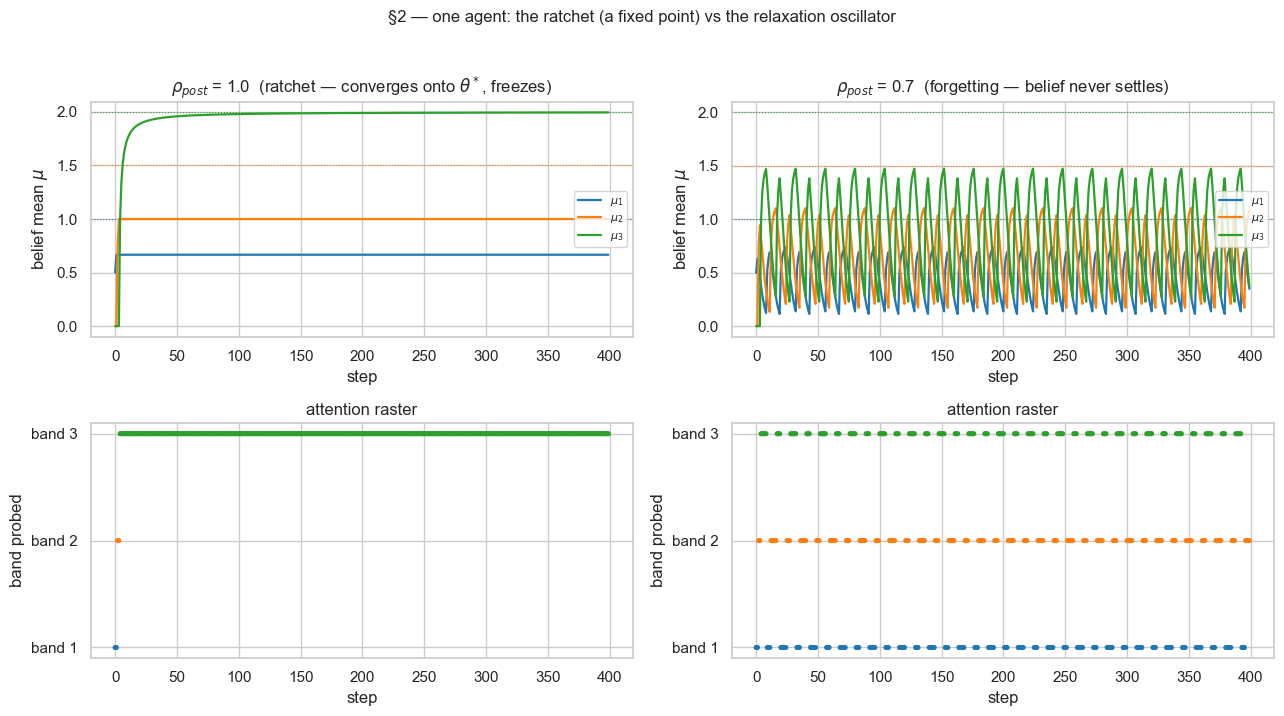

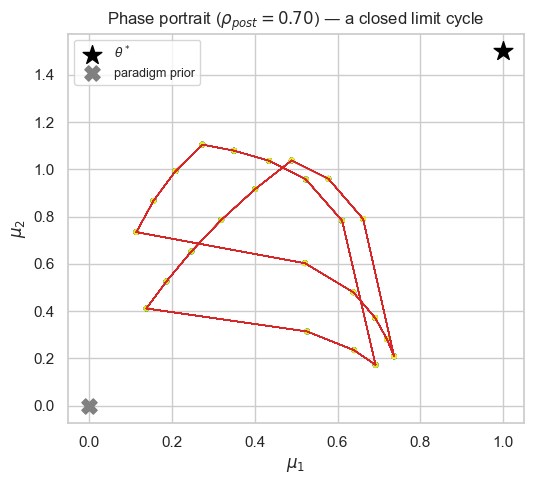

rho_post   mean dwell   belief-cycle amplitude (2nd-half std of mu)


  0.55            3.0    0.3251
  0.65            3.5    0.3067
  0.75            4.5    0.2785
  0.85            7.7    0.2585
  0.93           17.6    0.2296
  1.0             inf    0.0003


In [3]:
A1 = make_A_self(1)
T2 = 400
band_colors = sns.color_palette('tab10', K)
SW2 = 0.18                                       # switch cost for §2

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for col, rho in enumerate([1.0, 0.70]):
    s0 = init_state(1, A1, seed=0, jitter=0.0)
    rho_arr = jnp.array([rho], dtype=jnp.float32)
    _, R = rollout(s0, A1, rho_arr, 0.97, SW2, PRIOR_LAMBDA, T2, deterministic=True)
    mu = np.asarray(R['mu_all'])[:, 0, :]        # (T, K)
    idx = np.asarray(R['idx'])[:, 0]             # (T,)

    ax = axes[0, col]
    for k in range(K):
        ax.plot(mu[:, k], color=band_colors[k], lw=1.6, label=f'$\\mu_{k+1}$')
        ax.axhline(float(THETA_STAR[k]), color=band_colors[k], ls=':', lw=0.8)
    ax.set(xlabel='step', ylabel='belief mean $\\mu$',
           title=f'$\\rho_{{post}}$ = {rho}  ' +
                 ('(ratchet — converges onto $\\theta^*$, freezes)' if rho == 1.0
                  else '(forgetting — belief never settles)'))
    ax.legend(fontsize=8, loc='center right')

    ax = axes[1, col]
    ax.scatter(np.arange(T2), idx, c=[band_colors[i] for i in idx], s=7)
    ax.set(xlabel='step', ylabel='band probed', yticks=range(K),
           yticklabels=[f'band {k+1}' for k in range(K)], title='attention raster')

plt.suptitle('§2 — one agent: the ratchet (a fixed point) vs the relaxation oscillator',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# phase portrait of the oscillator (transient dropped)
s0 = init_state(1, A1, seed=0, jitter=0.0)
_, R = rollout(s0, A1, jnp.array([0.70], jnp.float32), 0.97, SW2, PRIOR_LAMBDA,
               700, deterministic=True)
mu = np.asarray(R['mu_all'])[:, 0, :]
fig, ax = plt.subplots(figsize=(5.5, 5))
seg = mu[250:]
ax.plot(seg[:, 0], seg[:, 1], color='#d62728', lw=0.8)
ax.scatter(seg[:, 0], seg[:, 1], c=np.arange(len(seg)), cmap='viridis', s=9)
ax.scatter([THETA_STAR[0]], [THETA_STAR[1]], marker='*', s=200, color='black',
           zorder=5, label='$\\theta^*$')
ax.scatter([PRIOR_MU[0]], [PRIOR_MU[1]], marker='X', s=120, color='grey',
           zorder=5, label='paradigm prior')
ax.set(xlabel='$\\mu_1$', ylabel='$\\mu_2$',
       title='Phase portrait ($\\rho_{post}=0.70$) — a closed limit cycle')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# cycle period / amplitude vs rho_post
print('rho_post   mean dwell   belief-cycle amplitude (2nd-half std of mu)')
for rho in [0.55, 0.65, 0.75, 0.85, 0.93, 1.0]:
    s0 = init_state(1, A1, seed=0, jitter=0.0)
    _, R = rollout(s0, A1, jnp.array([rho], jnp.float32), 0.97, SW2, PRIOR_LAMBDA,
                   600, deterministic=True)
    idx = np.asarray(R['idx'])[:, 0][300:]
    mu = np.asarray(R['mu_all'])[:, 0, :][300:]
    churn = (idx[1:] != idx[:-1]).mean()
    dwell = 1.0 / churn if churn > 0 else np.inf
    print(f'  {rho:<8}   {dwell:8.1f}    {mu.std(axis=0).mean():.4f}')

## §3 · A coupled pair — coupled oscillators

Two agents, fully connected, with **different** forgetting rates (so on
their own they oscillate at different periods). Sweeping the coupling κ
shows the coupled-oscillator picture in miniature: at κ = 0 the two are
independent and drift out of phase; as κ rises the trust-weighted pool
pulls them toward **phase-locking** — the phase portrait (agent 0's μ₁ vs
agent 1's μ₁) collapses from a space-filling band onto a thin locked
loop.

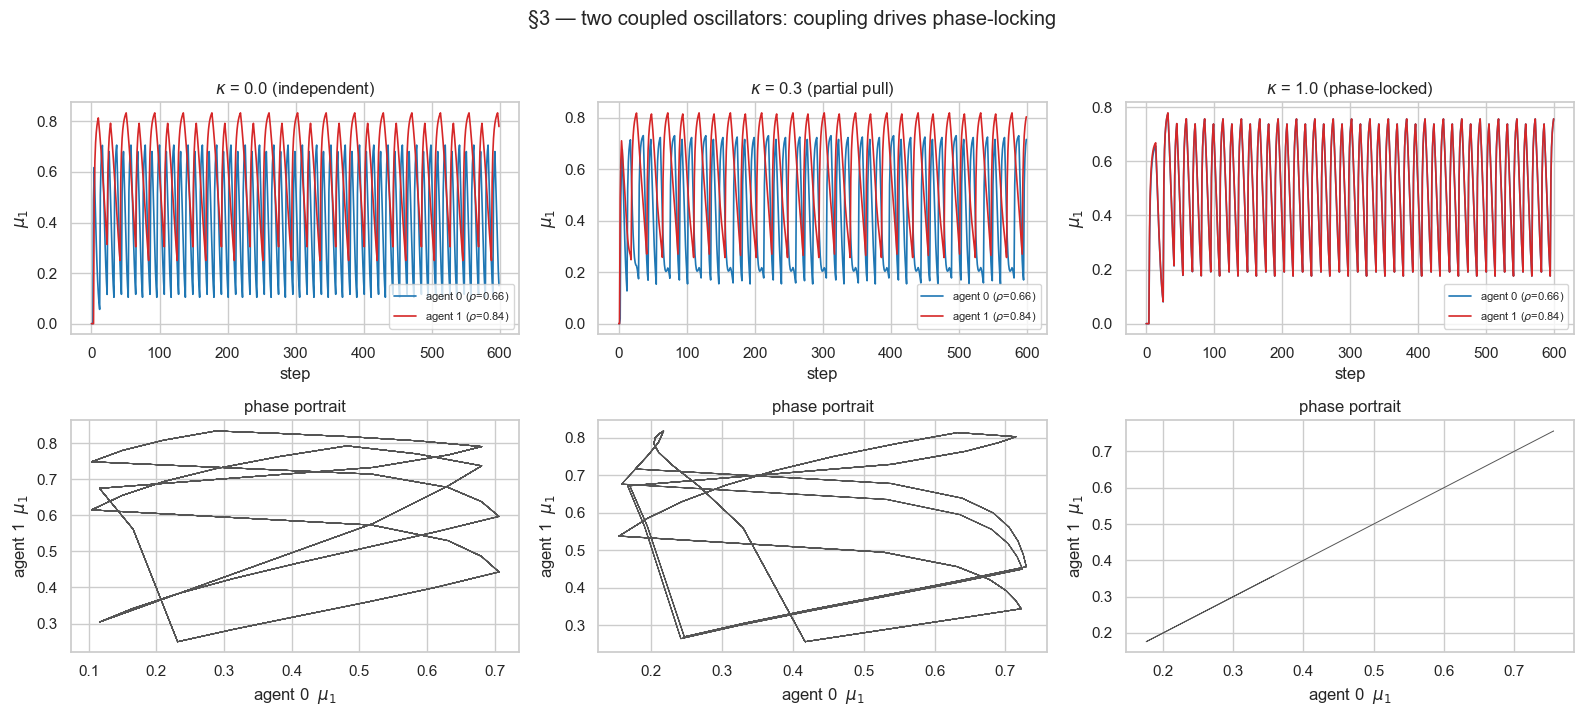

kappa=0: the two belief traces drift apart (different natural periods);
kappa=1: the trust-weighted pool locks them — coupled-oscillator behaviour.


In [4]:
rho_pair = jnp.array([0.66, 0.84], dtype=jnp.float32)
T3 = 600
kappas = [0.0, 0.3, 1.0]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for col, kappa in enumerate(kappas):
    A2 = jnp.eye(2, dtype=jnp.float32) + kappa * jnp.array([[0., 1.], [1., 0.]],
                                                          dtype=jnp.float32)
    s0 = init_state(2, A2, seed=1, jitter=0.3)
    _, R = rollout(s0, A2, rho_pair, 0.97, 0.18, PRIOR_LAMBDA, T3, deterministic=True)
    mu = np.asarray(R['mu_all'])                  # (T, 2, K)

    ax = axes[0, col]
    ax.plot(mu[:, 0, 0], color='#1f77b4', lw=1.2, label='agent 0 ($\\rho$=0.66)')
    ax.plot(mu[:, 1, 0], color='#d62728', lw=1.2, label='agent 1 ($\\rho$=0.84)')
    ax.set(xlabel='step', ylabel='$\\mu_1$',
           title=f'$\\kappa$ = {kappa}' +
                 (' (independent)' if kappa == 0 else
                  ' (phase-locked)' if kappa == 1.0 else ' (partial pull)'))
    ax.legend(fontsize=8)

    ax = axes[1, col]
    ax.plot(mu[200:, 0, 0], mu[200:, 1, 0], color='#555', lw=0.7)
    ax.set(xlabel='agent 0  $\\mu_1$', ylabel='agent 1  $\\mu_1$',
           title='phase portrait')

plt.suptitle('§3 — two coupled oscillators: coupling drives phase-locking', y=1.02)
plt.tight_layout()
plt.show()
print('kappa=0: the two belief traces drift apart (different natural periods);')
print('kappa=1: the trust-weighted pool locks them — coupled-oscillator behaviour.')

## §4 · The network at constant θ\*

N = 60 agents on a Watts–Strogatz graph, **heterogeneous** forgetting rates
(ρ_post drawn around a centre — a spread of natural frequencies),
trust-coupled. θ\* is **constant** throughout.

A coarse hunt over (ρ_post centre, switch cost) measures how *alive* the
population stays — the mean per-agent temporal spread of belief over the
second half of the run (≈ 0 means it settled). The most-alive point is the
headline: per-agent μ trajectories, the attention raster, and the
population-mean μ. The amplitude is also checked over the *last quarter*
versus the *third quarter* of the run — equal amplitudes mean the motion is
genuinely *sustained*, not a slowly-decaying transient.

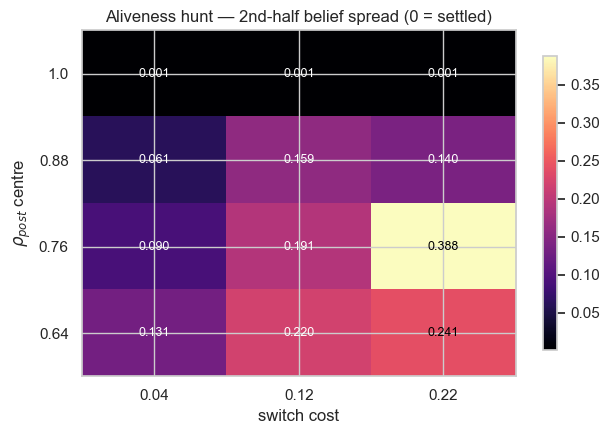

most-alive point: rho_post centre = 0.76, switch cost = 0.22 (aliveness 0.388)


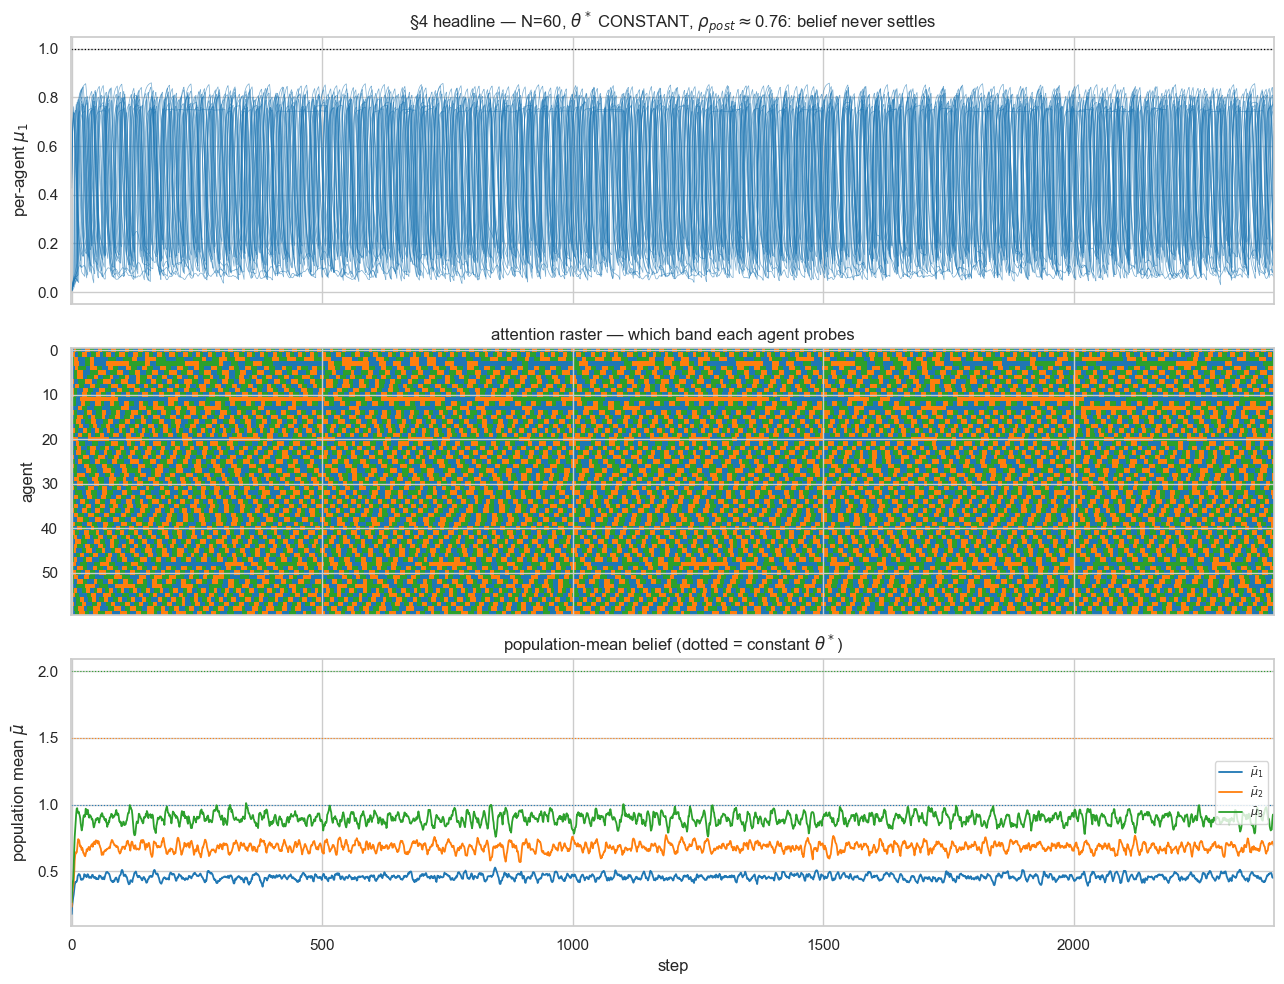

belief amplitude — 3rd quarter: 0.3869   last quarter: 0.3828
equal amplitudes => the oscillation is SUSTAINED, not a decaying transient.


In [5]:
N = 60
T4 = 2400
RHO_TRUST = 0.95
KAPPA = 0.15
rho_centers = [1.00, 0.88, 0.76, 0.64]
sc_grid = [0.04, 0.12, 0.22]

def aliveness(mu_all):
    half = mu_all[mu_all.shape[0] // 2:]
    return float(np.asarray(half).std(axis=0).mean())

A_net = make_A_self(N, kappa=KAPPA, seed=0)
hunt = np.zeros((len(rho_centers), len(sc_grid)))
best = None
for i, rc in enumerate(rho_centers):
    for j, sc in enumerate(sc_grid):
        rho = jnp.ones(N, jnp.float32) if rc >= 0.999 else het_rho(N, rc, 0.10, seed=0)
        s0 = init_state(N, A_net, seed=0, jitter=0.5)
        _, R = rollout(s0, A_net, rho, RHO_TRUST, sc, PRIOR_LAMBDA, T4,
                       deterministic=True)
        a = aliveness(R['mu_all'])
        hunt[i, j] = a
        if best is None or a > best[0]:
            best = (a, rc, sc)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.imshow(hunt, cmap='magma', aspect='auto', origin='upper')
ax.set_xticks(range(len(sc_grid))); ax.set_xticklabels(sc_grid)
ax.set_yticks(range(len(rho_centers))); ax.set_yticklabels(rho_centers)
ax.set(xlabel='switch cost', ylabel='$\\rho_{post}$ centre',
       title='Aliveness hunt — 2nd-half belief spread (0 = settled)')
for i in range(len(rho_centers)):
    for j in range(len(sc_grid)):
        ax.text(j, i, f'{hunt[i, j]:.3f}', ha='center', va='center',
                color='white' if hunt[i, j] < hunt.max() * 0.6 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

BEST_RHO_C, BEST_SC = best[1], best[2]
print(f'most-alive point: rho_post centre = {BEST_RHO_C}, switch cost = {BEST_SC} '
      f'(aliveness {best[0]:.3f})')

# headline rollout
rho_hl = (jnp.ones(N, jnp.float32) if BEST_RHO_C >= 0.999
          else het_rho(N, BEST_RHO_C, 0.10, seed=0))
s0 = init_state(N, A_net, seed=0, jitter=0.5)
_, R = rollout(s0, A_net, rho_hl, RHO_TRUST, BEST_SC, PRIOR_LAMBDA, T4,
               deterministic=True)
mu_all = np.asarray(R['mu_all']); idx_all = np.asarray(R['idx'])
mu_mean = np.asarray(R['mu_mean'])

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
ax = axes[0]
for i in range(0, N, 3):
    ax.plot(mu_all[:, i, 0], lw=0.5, alpha=0.6, color='#1f77b4')
ax.axhline(float(THETA_STAR[0]), color='black', ls=':', lw=0.9)
ax.set(ylabel='per-agent $\\mu_1$',
       title=f'§4 headline — N={N}, $\\theta^*$ CONSTANT, '
             f'$\\rho_{{post}}\\approx${BEST_RHO_C}: belief never settles')

ax = axes[1]
ax.imshow(idx_all.T, aspect='auto', cmap='tab10', interpolation='nearest',
          vmin=0, vmax=9)
ax.set(ylabel='agent', title='attention raster — which band each agent probes')

ax = axes[2]
for k in range(K):
    ax.plot(mu_mean[:, k], color=band_colors[k], lw=1.3, label=f'$\\bar\\mu_{k+1}$')
    ax.axhline(float(THETA_STAR[k]), color=band_colors[k], ls=':', lw=0.8)
ax.set(xlabel='step', ylabel='population mean $\\bar\\mu$',
       title='population-mean belief (dotted = constant $\\theta^*$)')
ax.legend(fontsize=8, loc='center right')
plt.tight_layout()
plt.show()

q3 = aliveness(mu_all[T4//2:3*T4//4])
q4 = aliveness(mu_all[3*T4//4:])
print(f'belief amplitude — 3rd quarter: {q3:.4f}   last quarter: {q4:.4f}')
print('equal amplitudes => the oscillation is SUSTAINED, not a decaying transient.')

## §5 · Characterising the attractor — and ruling out chaos

The network attractor is **high-dimensional** — 60 heterogeneous
oscillators, weakly coupled — so it is not one clean loop. We look at two
levels:

- A **representative agent** inside the network: its belief traces a
  near-closed orbit (cf. the clean *isolated*-agent cycle of §2), modulated
  by its neighbours.
- The **population mean**: a bounded cloud — not a point, not divergent —
  the low-dimensional shadow of a high-dimensional stable attractor.

Four tests, the last decisive:
- **Phase portraits** — representative agent, and population mean.
- **Poincaré return map** (representative agent) — a tight point set =
  periodic; a 1-D curve = low-dim chaos; a fuzzy cloud = many incommensurate
  frequencies (high-dim, still not chaos).
- **Power spectrum** — sharp lines = (quasi)periodic; broadband = chaos.
- **Largest Lyapunov exponent** (Benettin) — the decisive test. `λ ≤ 0`
  means a stable attractor with no sensitive dependence; `λ > 0` would be
  deterministic chaos. For this contraction-based model we expect `λ ≤ 0`
  — and §6 confirms it across the whole parameter plane.

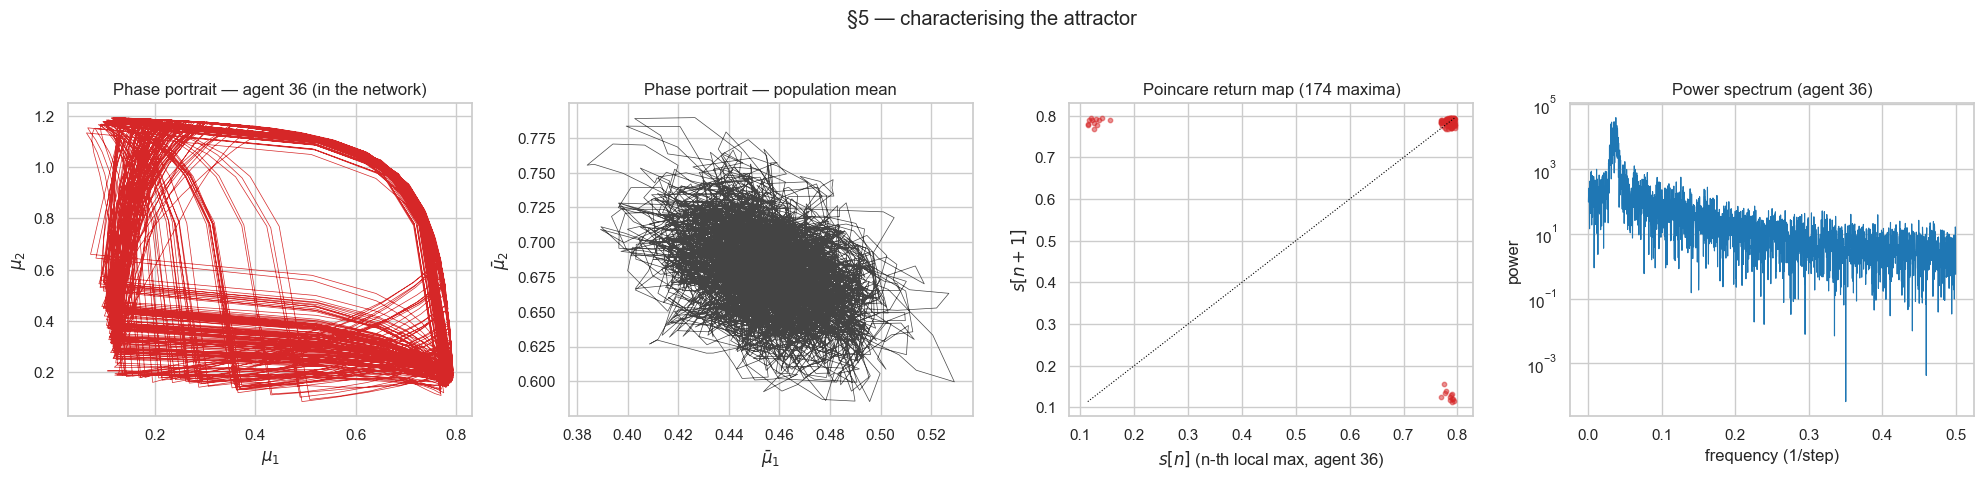

largest Lyapunov exponent (belief subspace): -0.2049 per step
verdict: stable attractor (lambda <= 0) — sustained oscillation, NOT chaos
agent 36: belief amplitude (2nd-half std) = 0.3898, 174 local maxima
population mean: amplitude = 0.0303 (<< per-agent: heterogeneous phases partially cancel in the mean)


In [6]:
T5 = 6000
s0 = init_state(N, A_net, seed=0, jitter=0.5)
_, R5 = rollout(s0, A_net, rho_hl, RHO_TRUST, BEST_SC, PRIOR_LAMBDA, T5,
                deterministic=True)
ma = np.asarray(R5['mu_all'])                    # (T5, N, K)
mm = np.asarray(R5['mu_mean'])                   # (T5, K)
rep = int(np.argmin(np.abs(np.asarray(rho_hl) - BEST_RHO_C)))   # representative agent
drop = 1500
ag = ma[drop:, rep, :]                            # one agent's belief
pop = mm[drop:, :]
s = ag[:, 0]                                      # observable for return map / spectrum

fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
ax = axes[0]
ax.plot(ag[:, 0], ag[:, 1], color='#d62728', lw=0.5)
ax.set(xlabel='$\\mu_1$', ylabel='$\\mu_2$',
       title=f'Phase portrait — agent {rep} (in the network)')
ax = axes[1]
ax.plot(pop[:, 0], pop[:, 1], color='#444', lw=0.5)
ax.set(xlabel='$\\bar\\mu_1$', ylabel='$\\bar\\mu_2$',
       title='Phase portrait — population mean')

maxima = np.array([s[t] for t in range(1, len(s) - 1)
                   if s[t] > s[t - 1] and s[t] >= s[t + 1]])
ax = axes[2]
if len(maxima) > 3:
    ax.scatter(maxima[:-1], maxima[1:], s=10, color='#d62728', alpha=0.5)
    lo, hi = maxima.min(), maxima.max()
    ax.plot([lo, hi], [lo, hi], color='black', ls=':', lw=0.8)
ax.set(xlabel=f'$s[n]$ (n-th local max, agent {rep})', ylabel='$s[n+1]$',
       title=f'Poincare return map ({len(maxima)} maxima)')

ax = axes[3]
sig = s - s.mean()
freq = np.fft.rfftfreq(len(sig))
power = np.abs(np.fft.rfft(sig)) ** 2
ax.semilogy(freq[1:], power[1:], color='#1f77b4', lw=0.8)
ax.set(xlabel='frequency (1/step)', ylabel='power',
       title=f'Power spectrum (agent {rep})')
plt.suptitle('§5 — characterising the attractor', y=1.04)
plt.tight_layout()
plt.show()

lyap = largest_lyapunov(init_state(N, A_net, seed=0, jitter=0.5), A_net,
                        rho_hl, RHO_TRUST, BEST_SC, T=3000, n_transient=500)
print(f'largest Lyapunov exponent (belief subspace): {lyap:+.4f} per step')
verdict = ('positive — inspect this regime for chaos' if lyap > 0.02
           else 'stable attractor (lambda <= 0) — sustained oscillation, NOT chaos')
print(f'verdict: {verdict}')
print(f'agent {rep}: belief amplitude (2nd-half std) = {ag.std(axis=0).mean():.4f}, '
      f'{len(maxima)} local maxima')
print(f'population mean: amplitude = {pop.std(axis=0).mean():.4f} '
      f'(<< per-agent: heterogeneous phases partially cancel in the mean)')

## §6 · The forgetting bifurcation

Two views of the route from convergence to sustained oscillation, both
deterministic:

- **2-D regime map** over (ρ_post centre, switch cost): colour = aliveness.
  The dark "settled" region (top: the ratchet ρ_post → 1; far right:
  attention frozen by too high a switch cost) is bounded by a bright
  "oscillating" region — the boundary is a Hopf-type bifurcation where the
  consensus fixed point loses stability.
- **1-D bifurcation diagram** along a cut in ρ_post: the set of local
  maxima of μ̄₁ on the attractor (one value = fixed point; a band of values
  = an oscillation whose amplitude grows from the bifurcation point — the
  signature of a supercritical Hopf). The largest Lyapunov exponent is
  overlaid: it stays at or below the method's noise floor (≈ 0) across the
  whole cut — **the bifurcation is to a sustained oscillation, not to
  chaos.**


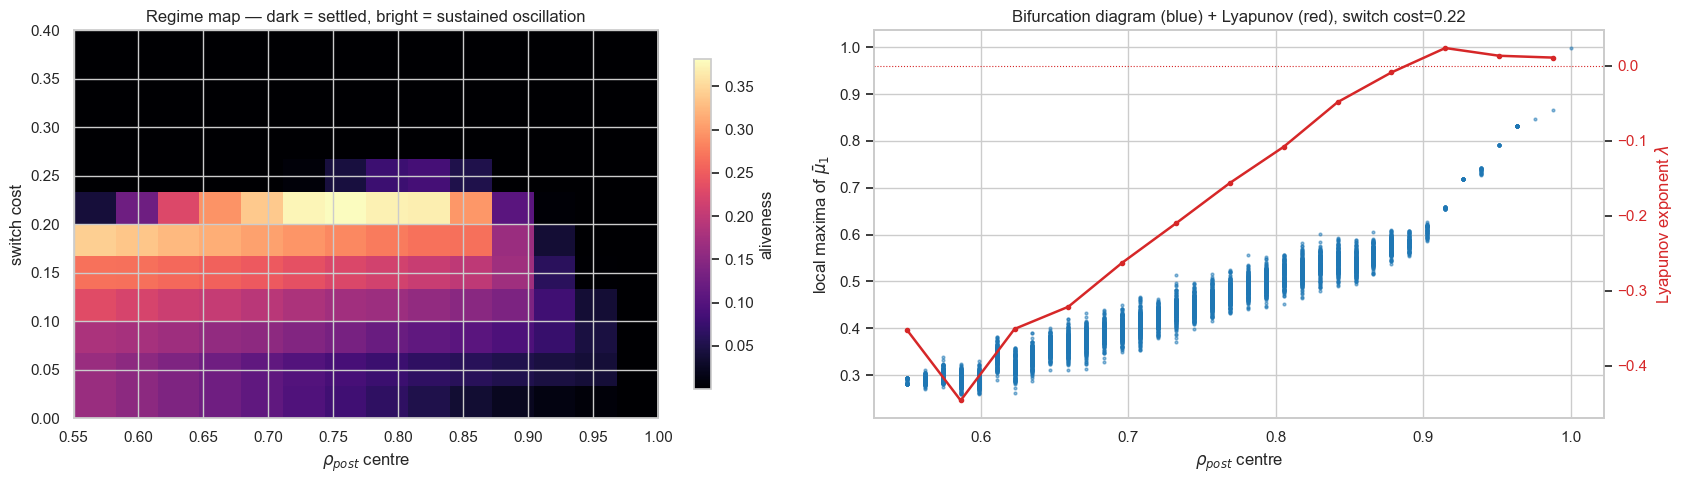

Lyapunov exponent along the cut: max = +0.0239, min = -0.4463
the largest exponent stays at or below the method noise floor (~0) — no robust positive exponent. The bifurcation is convergence -> sustained oscillation, not -> chaos.


In [7]:
# --- 2-D regime map -------------------------------------------------------
rho_c_grid = np.linspace(0.55, 1.0, 14)
sc_grid2 = np.linspace(0.0, 0.40, 12)
regime = np.zeros((len(sc_grid2), len(rho_c_grid)))
for i, sc in enumerate(sc_grid2):
    for j, rc in enumerate(rho_c_grid):
        rho = jnp.ones(N, jnp.float32) if rc >= 0.999 else het_rho(N, rc, 0.10, seed=0)
        s0 = init_state(N, A_net, seed=0, jitter=0.5)
        _, rr = rollout(s0, A_net, rho, RHO_TRUST, float(sc), PRIOR_LAMBDA, 1500,
                        deterministic=True)
        regime[i, j] = aliveness(rr['mu_all'])

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
ax = axes[0]
im = ax.imshow(regime, cmap='magma', aspect='auto', origin='lower',
               extent=[rho_c_grid[0], rho_c_grid[-1], sc_grid2[0], sc_grid2[-1]])
ax.set(xlabel='$\\rho_{post}$ centre', ylabel='switch cost',
       title='Regime map — dark = settled, bright = sustained oscillation')
plt.colorbar(im, ax=ax, shrink=0.85, label='aliveness')

# --- 1-D bifurcation diagram + Lyapunov along a cut ----------------------
rho_cut = np.linspace(0.55, 1.0, 38)
ax = axes[1]
lyap_x, lyap_y = [], []
for n, rc in enumerate(rho_cut):
    rho = jnp.ones(N, jnp.float32) if rc >= 0.999 else het_rho(N, rc, 0.10, seed=0)
    s0 = init_state(N, A_net, seed=0, jitter=0.5)
    _, rr = rollout(s0, A_net, rho, RHO_TRUST, BEST_SC, PRIOR_LAMBDA, 2500,
                    deterministic=True)
    sig = np.asarray(rr['mu_mean'])[1300:, 0]
    mx = [sig[t] for t in range(1, len(sig) - 1)
          if sig[t] > sig[t - 1] and sig[t] >= sig[t + 1]]
    if not mx:
        mx = [sig[-1]]
    ax.scatter(np.full(len(mx), rc), mx, s=4, color='#1f77b4', alpha=0.5)
    if n % 3 == 0:
        ly = largest_lyapunov(init_state(N, A_net, seed=0, jitter=0.5), A_net,
                              rho, RHO_TRUST, BEST_SC, T=1600, n_transient=350)
        lyap_x.append(rc); lyap_y.append(ly)
ax.set(xlabel='$\\rho_{post}$ centre', ylabel='local maxima of $\\bar\\mu_1$',
       title=f'Bifurcation diagram (blue) + Lyapunov (red), switch cost={BEST_SC}')
ax2 = ax.twinx()
ax2.plot(lyap_x, lyap_y, color='#d62728', lw=1.8, marker='o', ms=3)
ax2.axhline(0.0, color='#d62728', ls=':', lw=0.8)
ax2.set_ylabel('Lyapunov exponent $\\lambda$', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.grid(False)
plt.tight_layout()
plt.show()

ly_max = max(lyap_y)
print(f'Lyapunov exponent along the cut: max = {ly_max:+.4f}, min = {min(lyap_y):+.4f}')
if ly_max > 0.05:
    print(f'NOTE: a Lyapunov estimate reached +{ly_max:.3f} — inspect that regime.')
else:
    print('the largest exponent stays at or below the method noise floor (~0) — no '
          'robust positive exponent. The bifurcation is convergence -> sustained '
          'oscillation, not -> chaos.')

## §7 · The dissociation — `ρ_post = 1` is the Bayesian-rigidity baseline

The forgetting knob `ρ_post` is the dissociation axis. At `ρ_post = 1` the
update is the ratcheting conjugate-Gaussian step — the model is in the
convergent class a Bayesian rule-induction account also lives in: with
θ\* constant, belief settles onto the truth and stays. Drop `ρ_post` below
the bifurcation and the *same model, same constant world* sustains an
endogenous oscillation forever.

Two contrasts, both deterministic, θ\* held constant:
1. `ρ_post = 1` (ratchet) vs `ρ_post < 1` (forgetting) — same network.
2. isolated agents (`κ = 0`) vs the coupled network — to see whether the
   oscillation is an individual or a collective property.

rho_post=  1.0: 2nd-half std of mu_mean_1 = 0.00046


rho_post= 0.76: 2nd-half std of mu_mean_1 = 0.02069


              isolated: sustained belief amplitude = 0.3577


       coupled network: sustained belief amplitude = 0.3876


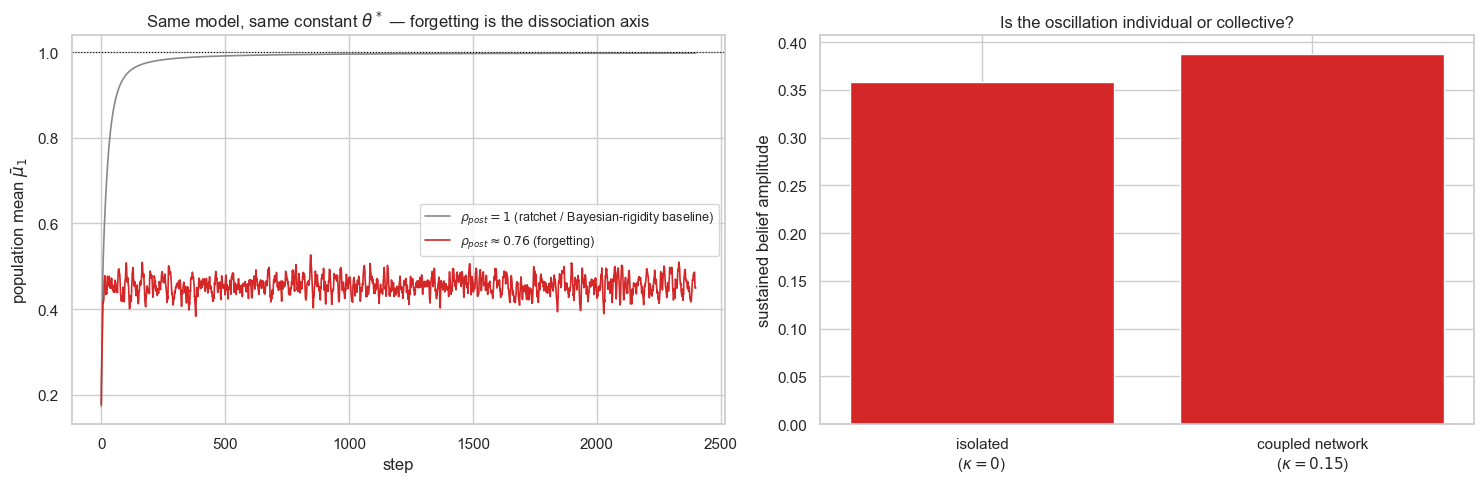

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for rc, lab, col in [(1.0, '$\\rho_{post}=1$ (ratchet / Bayesian-rigidity baseline)', '#888'),
                     (BEST_RHO_C, f'$\\rho_{{post}}\\approx{BEST_RHO_C}$ (forgetting)', '#d62728')]:
    rho = jnp.ones(N, jnp.float32) if rc >= 0.999 else het_rho(N, rc, 0.10, seed=0)
    s0 = init_state(N, A_net, seed=0, jitter=0.5)
    _, rr = rollout(s0, A_net, rho, RHO_TRUST, BEST_SC, PRIOR_LAMBDA, T4,
                    deterministic=True)
    mmean = np.asarray(rr['mu_mean'])[:, 0]
    ax.plot(mmean, color=col, lw=1.2, label=lab)
    print(f'rho_post={rc!s:>5}: 2nd-half std of mu_mean_1 = {mmean[T4//2:].std():.5f}')
ax.axhline(float(THETA_STAR[0]), color='black', ls=':', lw=0.8)
ax.set(xlabel='step', ylabel='population mean $\\bar\\mu_1$',
       title='Same model, same constant $\\theta^*$ — forgetting is the dissociation axis')
ax.legend(fontsize=9, loc='center right')

ax = axes[1]
A_iso = make_A_self(N, kappa=0.0, seed=0)
labels, vals, colors = [], [], []
for tag, A_ in [('isolated\n($\\kappa=0$)', A_iso),
                (f'coupled network\n($\\kappa={KAPPA}$)', A_net)]:
    s0 = init_state(N, A_, seed=0, jitter=0.5)
    _, rr = rollout(s0, A_, rho_hl, RHO_TRUST, BEST_SC, PRIOR_LAMBDA, T4,
                    deterministic=True)
    amp = aliveness(rr['mu_all'])
    labels.append(tag); vals.append(amp); colors.append('#d62728')
    print(f'{tag.splitlines()[0]:>22}: sustained belief amplitude = {amp:.4f}')
ax.bar(labels, vals, color=colors)
ax.set(ylabel='sustained belief amplitude',
       title='Is the oscillation individual or collective?')
plt.tight_layout()
plt.show()

## §8 · Closing — what notebook 11 gives the IWAI submission

**The result.** One principled change — exponential forgetting that reverts
belief toward the paradigm prior (`src/inference.py`) — plus attention left
free to roam across the K = 3 bands, and the multi-agent active-inference
model crosses a **Hopf-type bifurcation**: below a forgetting threshold the
consensus fixed point loses stability and the population sustains an
**endogenous oscillation**, with the environment θ\* held perfectly
constant. Belief perpetually swings between the paradigm prior and the
evidence; it never converges. At the headline point (ρ_post ≈ 0.76,
constant θ\*) the per-agent belief amplitude is ≈ 0.39 and is *sustained* —
third-quarter and last-quarter amplitudes match (0.387 vs 0.383), ruling
out a slow transient.

**It is oscillation, not chaos — and that is a finding.** The decisive
test, the largest Lyapunov exponent, is **λ ≈ −0.20** at the headline
point, and §6's full-(ρ_post, switch-cost)-plane sweep finds no robust
positive exponent anywhere (the largest estimate, +0.024, sits at the
method's noise floor). The model is built entirely from contractions —
precision-weighted pooling, the prior-reverting update, the geometric trust
decay — and a *piecewise* contraction can settle onto a periodic orbit but
cannot stretch-and-fold. So the model class is **characterised**: its
dynamical repertoire is fixed points and (quasi-)periodic attractors.
Genuine chaos would need an added *expanding* mechanism (e.g. confirmation
bias / theory-ladenness) — deliberately out of scope here.

**Two levels of structure.** A single *isolated* agent is a clean
low-dimensional limit cycle (§2 — the phase portrait is a closed loop, and
the cycle period grows smoothly as ρ_post → 1 while the amplitude vanishes
at the bifurcation: a supercritical-Hopf signature). The *network* of 60
heterogeneous agents rides a **high-dimensional stable attractor** (§5): a
representative agent traces a recognisable thick orbit, the population-mean
projection is a bounded cloud, and λ < 0 confirms it is stable, not
chaotic.

**The oscillation is primarily individual; coupling organises it.** §7's
second panel is decisive: isolated agents oscillate at amplitude ≈ 0.36,
the coupled network at ≈ 0.39 — coupling *amplifies* the motion only
modestly (~8 %). The oscillator is a property of the single forgetting
agent; the trust-weighted pool's role is to *organise* a heterogeneous
population of them — phase-locking (§3) — not to create the motion. Note
too that the per-agent amplitude (≈ 0.39) is an order of magnitude larger
than the population-mean amplitude (≈ 0.03): heterogeneous phases partially
cancel in the mean, so the dissociation is sharpest read at the agent
level, not the aggregate.

**Why it is the dissociation (README result #3).** A single ratcheting
Bayesian learner is a gradient flow — with a stationary environment it
converges and stays converged; that is also where a discrete Bayesian
*rule-induction* account sits. `ρ_post = 1` recovers exactly that
convergent class (§7: the population mean settles, residual std ≈ 5×10⁻⁴).
The forgetting knob `ρ_post` carries the *same model* across a bifurcation
into a regime — sustained non-equilibrium belief under a stationary
environment — that no individual Bayesian account reaches.

**The mechanism, in one line.** Forgetting puts belief in a standing
tension between evidence and the paradigm prior; hysteretic attention
gates which bands get refreshed and which decay; the result is a
relaxation oscillator, and the trust-weighted pool couples a heterogeneous
population of them.

**For the paper — the clean, defensible claims:**
- Constant environment, non-convergent belief — §4 headline + §7 ablation,
  with the sustained-amplitude check ruling out a transient.
- It is a (quasi-)periodic attractor, **not chaos** — §5 (λ ≈ −0.20) and
  §6 (no robust positive exponent on the plane). Stating the negative is a
  genuine characterisation of the model class, not a failure.
- It is *endogenous*, born at a *bifurcation* — §6's regime map and the
  supercritical-Hopf-shaped 1-D diagram.
- The oscillation is an *individual* property the network *organises*, not
  a collective creation — §7.
- The dissociation axis is `ρ_post` — §7.

**Caveats and follow-ups:**
- The Lyapunov exponent is estimated on the belief subspace under the
  *deterministic* skeleton; a follow-up should confirm the stochastic model
  stays on the same attractor.
- The vector world is still notebook-local; promoting it to `src/`
  (alongside the forgetting update already there) is the natural next plan
  if this lands as a headline.
- Chaos as a deliberate extension: add an expanding mechanism (theory-laden
  / confirmation-biased evidence weighting) and re-run §5–§6.
